In [1]:
import platform
import sys
import keras
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

np.set_printoptions(threshold=sys.maxsize)
import pandas as pd

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)
import seaborn as sns

sns.set_style("whitegrid")
import tensorflow as tf
from IPython.display import display
from keras import models
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from keras.preprocessing import sequence
from keras.utils import np_utils
from keras.callbacks import ModelCheckpoint, EarlyStopping
from matplotlib import font_manager, rc

path = r"C:\Windows\Fonts\malgun.ttf"
if platform.system() == "Darwin":
    rc("font", family="AppleGothic")
elif platform.system() == "Windows":
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc("font", family=font_name)
else:
    print("지원하지 않는 운영체제입니다.")
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

Using TensorFlow backend.


In [2]:
movie = pd.read_csv("./data/movie_onehot.csv")
movie.head()

rating = pd.read_csv("./data/rating_scale.csv")
rating.head()

movie = movie.drop("Unnamed: 0", axis=1)
movie.head()

rating = rating.drop("Unnamed: 0", axis=1)
rating.head()
# rating_del_neutral = rating[rating['rating_scale'] != 'Neutral']

genre_unique = movie.columns.tolist()
user_unique = rating["userId"].unique().tolist()

In [3]:
rating.loc[rating["rating"] < 0.5, "rating_scale"] = 0
rating.loc[rating["rating"] >= 0.5, "rating_scale"] = 1

rating_del_neutral = rating.drop("rating", axis=1)

merge = pd.merge(rating, movie, on="movieId")
merge = merge.sort_values(["userId"], ascending=[True])
merge = merge.reset_index(drop=True)

In [4]:
# rating.loc[(rating['rating'] > 0.5) & (rating['rating'] < 0.6), 'rating_scale'] = 0

In [5]:
merge["rating_scale"].value_counts()

1    22759423
0     4994021
Name: rating_scale, dtype: int64

In [6]:
merge.head()

,userId,movieId,rating,rating_scale,Adventure,Comedy,Action,Drama,Crime,Children,Mystery,Documentary,Animation,Thriller,Horror,Fantasy,Western,Film-Noir,Romance,War,Sci-Fi,Musical,IMAX,(no genres listed)
0,1,307,0.666667,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1590,0.444444,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0
2,1,2986,0.444444,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
3,1,1257,0.888889,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,1,481,0.666667,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [7]:
rating = pd.read_csv("./data/ratings_sum.csv")
rating.head()

,Adventure,Comedy,Action,Drama,Crime,Children,Mystery,Documentary,Animation,Thriller,Horror,Fantasy,Western,Film-Noir,Romance,War,Sci-Fi,Musical,IMAX,userId
0,-1.0,3.0,-1.0,2.0,-1.0,0.0,0.0,0.0,0.0,-4.0,-2.0,1.0,1.0,0.0,1.0,0.0,-3.0,0.0,0.0,1
1,0.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,2
2,1.0,1.0,1.0,4.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3
3,64.0,-19.0,127.0,92.0,68.0,-11.0,25.0,2.0,9.0,125.0,14.0,22.0,-3.0,3.0,4.0,20.0,42.0,-3.0,5.0,4
4,6.0,15.0,12.0,44.0,29.0,0.0,11.0,2.0,0.0,21.0,0.0,2.0,2.0,2.0,8.0,8.0,3.0,0.0,1.0,5


In [8]:
rating.drop("userId", inplace=True, axis=1)

In [9]:
rating["max"] = rating.idxmax(axis=1)

In [10]:
temp = rating["max"]
temp.head()

0           Comedy
1            Drama
2            Drama
3           Action
4            Drama
Name: max, Length: 281569, dtype: object

In [11]:
ratings = rating.drop("max", axis=1)
ratings.head()

,Adventure,Comedy,Action,Drama,Crime,Children,Mystery,Documentary,Animation,Thriller,Horror,Fantasy,Western,Film-Noir,Romance,War,Sci-Fi,Musical,IMAX
0,-1.0,3.0,-1.0,2.0,-1.0,0.0,0.0,0.0,0.0,-4.0,-2.0,1.0,1.0,0.0,1.0,0.0,-3.0,0.0,0.0
1,0.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0
2,1.0,1.0,1.0,4.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,64.0,-19.0,127.0,92.0,68.0,-11.0,25.0,2.0,9.0,125.0,14.0,22.0,-3.0,3.0,4.0,20.0,42.0,-3.0,5.0
4,6.0,15.0,12.0,44.0,29.0,0.0,11.0,2.0,0.0,21.0,0.0,2.0,2.0,2.0,8.0,8.0,3.0,0.0,1.0


In [12]:
# rating.drop('timestamp', axis=1, inplace=True)

In [13]:
# rating['rating']

In [14]:
mv = merge.drop(["rating", "(no genres listed)", "rating_scale", "userId"], axis=1)

In [15]:
user_rating = pd.DataFrame(
    index=range(0, 0),
    columns=[
        "Adventure",
        "Comedy",
        "Action",
        "Drama",
        "Crime",
        "Children",
        "Mystery",
        "Documentary",
        "Animation",
        "Thriller",
        "Horror",
        "Fantasy",
        "Western",
        "Film-Noir",
        "Romance",
        "War",
        "Sci-Fi",
        "Musical",
        "IMAX",
    ],
)
for _ in user_unique[:10]:
    # _ 번째 유저만 색인
    temp = merge[merge["userId"] == _]
    movie_list = temp["movieId"].unique().tolist()
    onehot_table = pd.DataFrame(
        index=range(0, 0),
        columns=[
            "Adventure",
            "Comedy",
            "Action",
            "Drama",
            "Crime",
            "Children",
            "Mystery",
            "Documentary",
            "Animation",
            "Thriller",
            "Horror",
            "Fantasy",
            "Western",
            "Film-Noir",
            "Romance",
            "War",
            "Sci-Fi",
            "Musical",
            "IMAX",
        ],
    )
    for item in movie_list:
        # 선호, 비선호 구분
        count = temp[temp["movieId"] == item].rating_scale
        onehot = temp[temp["movieId"] == item].apply(lambda x: x * count)
        onehot_table = onehot_table.append(onehot)
    #         .apply(lambda x : x * count)
    df_reindex = onehot_table.drop(
        ["rating_scale", "userId", "movieId", "(no genres listed)"], axis=1
    )
    rating_count = df_reindex.sum()
    to_dict = pd.DataFrame(rating_count).transpose()
    to_dict["userId"] = str(_)
    user_rating = user_rating.append(to_dict)

In [16]:
# movie_drop = merge.drop(['userId','movieId','(no genres listed)','rating','rating_scale'], axis=1)

In [17]:
rating = pd.read_csv("./data/ratings.csv")
aa = rating["movieId"]

In [18]:
aa.head()

0          307
1          481
2         1091
3         1257
4         1449
Name: movieId, Length: 281569, dtype: int64

In [19]:
merge["userId"].head()

0                1
1                1
2                1
3                1
4                1
Name: userId, Length: 27753444, dtype: int64

In [20]:
mvt = merge["rating_scale"]
mvt.head()

0           1
1           0
2           0
3           1
4           1
Name: rating_scale, Length: 27753444, dtype: object

In [21]:
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(mv, mvt, random_state=0)

In [23]:
X_train.shape

(20815083, 20)

In [25]:
y_train.shape

(20815083,)

In [27]:
model = Sequential()
model.add(Embedding(1000, 100))
model.add(LSTM(100, input_dim=19, activation="relu"))
model.add(
    Dense(
        180,
        kernel_initializer="random_normal",
        bias_initializer="Constant",
        activation="relu",
    )
)
model.add(Dense(150, bias_initializer="Constant", activation="relu"))
model.add(Dense(120, activation="relu"))
model.add(Dense(90, activation="relu"))
model.add(Dense(60, activation="relu"))
model.add(Dense(30, activation="relu"))
model.add(Dense(10, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: UserWarning: The `input_dim` and `input_length` arguments in recurrent layers are deprecated. Use `input_shape` instead.
  This is separate from the ipykernel package so we can avoid doing imports until
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: UserWarning: Update your `LSTM` call to the Keras 2 API: `LSTM(100, activation="relu", input_shape=(None, 19))`
  This is separate from the ipykernel package so we can avoid doing imports until


In [28]:
# model = Sequential()
# model.add(Embedding(23000, 100))
# model.add(LSTM(100, input_dim = 20, activation='relu'))
# model.add(Dense(38, kernel_initializer='random_normal', bias_initializer='Constant', activation='relu'))
# model.add(Dense(36, bias_initializer='Constant', activation='relu'))
# model.add(Dense(20, activation='relu'))
# # model.add(Dropout(0.25))
# model.add(Dense(18, activation='relu'))
# model.add(Dense(16, activation='relu'))
# model.add(Dense(1, activation='sigmoid'))

In [29]:
model.compile(loss="mean_squared_error", optimizer="adam", metrics=["accuracy"])

In [30]:
early_stopping_callback = EarlyStopping(monitor="val_loss", patience=5)

In [31]:
history = model.fit(
    X_train,
    y_train,
    batch_size=4500,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping_callback],
)

C:\ProgramData\Anaconda3\lib\site-packages\tensorflow_core\python\framework\indexed_slices.py:433: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "


Train on 20815083 samples, validate on 6938361 samples
Epoch 1/10
20815083/20815083 [==============================] - 263s 13us/step - loss: 0.1428 - accuracy: 0.8204 - val_loss: 0.1412 - val_accuracy: 0.8201
Epoch 2/10
20815083/20815083 [==============================] - 262s 13us/step - loss: 0.1402 - accuracy: 0.8211 - val_loss: 0.1398 - val_accuracy: 0.8212
Epoch 3/10
20815083/20815083 [==============================] - 243s 12us/step - loss: 0.1397 - accuracy: 0.8213 - val_loss: 0.1396 - val_accuracy: 0.8213
Epoch 4/10
20815083/20815083 [==============================] - 213s 10us/step - loss: 0.1396 - accuracy: 0.8214 - val_loss: 0.1395 - val_accuracy: 0.8213
Epoch 5/10
20815083/20815083 [==============================] - 231s 11us/step - loss: 0.1395 - accuracy: 0.8214 - val_loss: 0.1395 - val_accuracy: 0.8213
Epoch 6/10
20815083/20815083 [==============================] - 226s 11us/step - loss: 0.1395 - accuracy: 0.8214 - val_loss: 0.1395 - val_accuracy: 0.8213
Epoch 7/10
2081

In [32]:
y_pred = model.predict(X_test).flatten()
y_pred[:5]

array([0.9104176 , 0.88191926, 0.6660285 , 0.7432014 , 0.888619 ], dtype=float32)


In [33]:
print("\n Test Accuracy : ", (model.evaluate(X_test, y_test)[1]))

6938361/6938361 [==============================] - 703s 101us/step

 Test Accuracy :  0.8213887810707092


In [34]:
y_vloss = history.history["val_loss"]

In [35]:
y_loss = history.history["loss"]

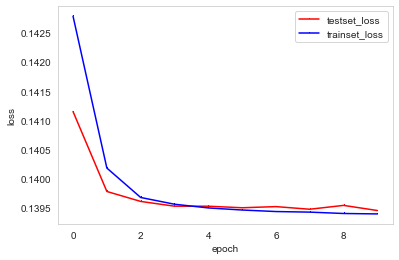

In [36]:
x_len = np.arange(len(y_loss))

plt.plot(x_len, y_vloss, marker=",", c="red", label="testset_loss")
plt.plot(x_len, y_loss, marker=",", c="blue", label="trainset_loss")
plt.legend()
plt.grid()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

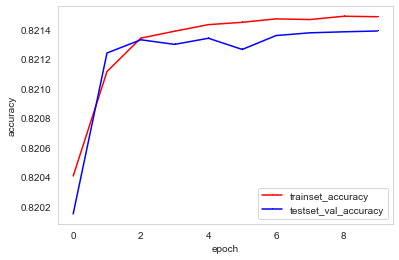

In [37]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
a_len = np.arange(len(accuracy))

plt.plot(a_len, accuracy, marker=",", c="red", label="trainset_accuracy")
plt.plot(a_len, val_accuracy, marker=",", c="blue", label="testset_val_accuracy")
plt.legend()
plt.grid()
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()